In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [4]:
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
# val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
class_mapping = train_generator.class_indices
print("Class Mapping:", class_mapping)

# reverse mapping
class_labels = {v:k for k,v in class_mapping.items()}

Class Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [8]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [9]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 813ms/step - accuracy: 0.6638 - loss: 0.6181 - val_accuracy: 0.7795 - val_loss: 0.5018
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 72s 548ms/step - accuracy: 0.8406 - loss: 0.3827 - val_accuracy: 0.8639 - val_loss: 0.3413
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 543ms/step - accuracy: 0.8771 - loss: 0.3002 - val_accuracy: 0.8591 - val_loss: 0.3244
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 537ms/step - accuracy: 0.8898 - loss: 0.2718 - val_accuracy: 0.8485 - val_loss: 0.3782
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 573ms/step - accuracy: 0.8982 - loss: 0.2639 - val_accuracy: 0.8821 - val_loss: 0.2930
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 570ms/step - accuracy: 0.9056 - loss: 0.2473 - val_accuracy: 0.8035 - val_loss: 0.5191
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 556ms/step - accuracy: 0.8962 - loss: 0.2598 - val_accuracy: 0.8907 - val_loss: 0.2600
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 557ms/step - accuracy: 0.9140 - loss: 

In [12]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 398ms/step - accuracy: 0.8958 - loss: 0.2579
Test Accuracy: 0.8958


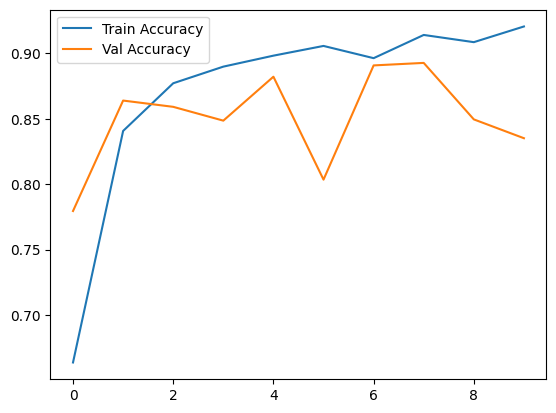

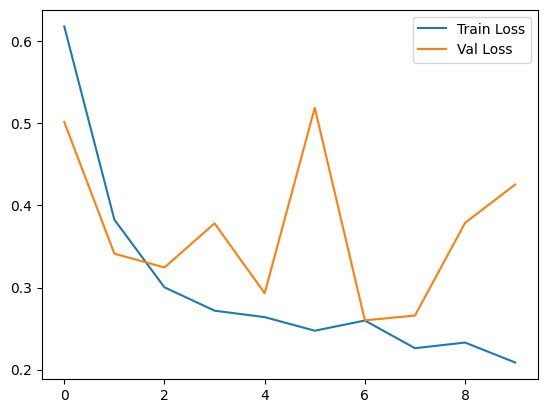

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
Raw Prediction: 0.99979043
Predicted Class: PNEUMONIA


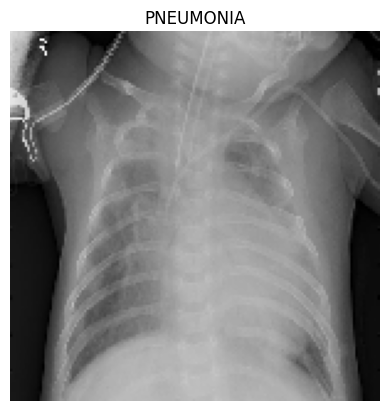

In [14]:
from tensorflow.keras.preprocessing import image

img_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1_virus_6.jpeg'

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Raw Prediction:", prediction)

if prediction > 0.5:
    predicted_class = class_labels[1]
else:
    predicted_class = class_labels[0]

print("Predicted Class:", predicted_class)

plt.imshow(img)
plt.title(predicted_class)
plt.axis('off')
plt.show()

In [16]:
model.save('pneumonia.keras')

In [17]:
model.save('pnue.h5')

In [21]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load the model
model = load_model('pneumonia.keras')

# Predict on new image - create a function
def predict(img_path):
  img = image.load_img(img_path, target_size=(150,150))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  prediction = model.predict(img_array)[0][0]

  print("Raw Prediction:", prediction)

  if prediction > 0.5:
      predicted_class = class_labels[1]
  else:
      predicted_class = class_labels[0]

  print("Predicted Class:", predicted_class)

  plt.imshow(img)
  plt.title(predicted_class)
  plt.axis('off')
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
Raw Prediction: 0.0006757807
Predicted Class: NORMAL


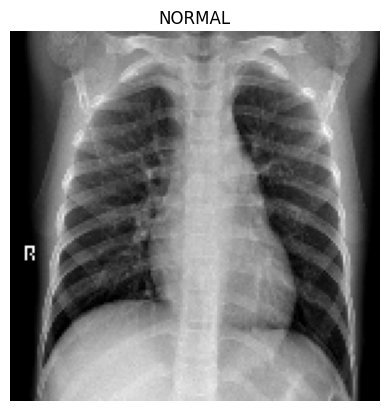

In [22]:
predict('/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0086-0001.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Raw Prediction: 0.010311454
Predicted Class: NORMAL


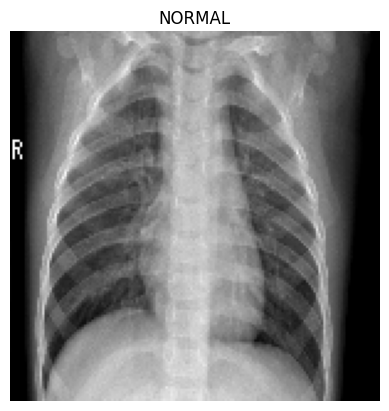

In [23]:
predict('/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0303-0001.jpeg')